/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataloader temporal windowing: extending data collection from 2006-05-15 to 2006-02-06 (+14 weeks)


/home/de-schrijvers/projects/germany_gnn/src/dataloading/epidataloader.py:209: UserWarning: 12 rows with missing tokenized IDs will be dropped from 'shapedata'. Dropped original IDs: ['11012' '11004' '11009' '11003' '11008' '11011' '11010' '11005' '11006'
 '11001' '11002' '11007']
  warnings.warn(


Epoch 1 train loss: 0.8104, val loss: 1.6182 ✓ (new best)
Epoch 2 train loss: 0.7140, val loss: 1.3051 ✓ (new best)
Epoch 3 train loss: 0.6314, val loss: 1.0459 ✓ (new best)
Epoch 4 train loss: 0.5564, val loss: 0.8123 ✓ (new best)
Epoch 5 train loss: 0.4998, val loss: 0.6457 ✓ (new best)
Epoch 6 train loss: 0.4629, val loss: 0.5447 ✓ (new best)
Epoch 7 train loss: 0.4396, val loss: 0.4858 ✓ (new best)
Epoch 8 train loss: 0.4254, val loss: 0.4534 ✓ (new best)
Epoch 9 train loss: 0.4169, val loss: 0.4341 ✓ (new best)
Epoch 10 train loss: 0.4082, val loss: 0.4184 ✓ (new best)
Epoch 11 train loss: 0.4034, val loss: 0.4089 ✓ (new best)
Epoch 12 train loss: 0.4008, val loss: 0.4054 ✓ (new best)
Epoch 13 train loss: 0.3964, val loss: 0.3981 ✓ (new best)
Epoch 14 train loss: 0.3952, val loss: 0.3946 ✓ (new best)
Epoch 15 train loss: 0.3900, val loss: 0.3892 ✓ (new best)
Epoch 16 train loss: 0.3860, val loss: 0.3871 ✓ (new best)
Epoch 17 train loss: 0.3839, val loss: 0.3856 ✓ (new best)
Epoch 

(<Figure size 1600x1000 with 2 Axes>,
 array([<Axes: title={'center': 'National aggregation of incidence'}, ylabel='incidence'>,
        <Axes: title={'center': 'predictions node: 26'}, ylabel='incidence'>],
       dtype=object))

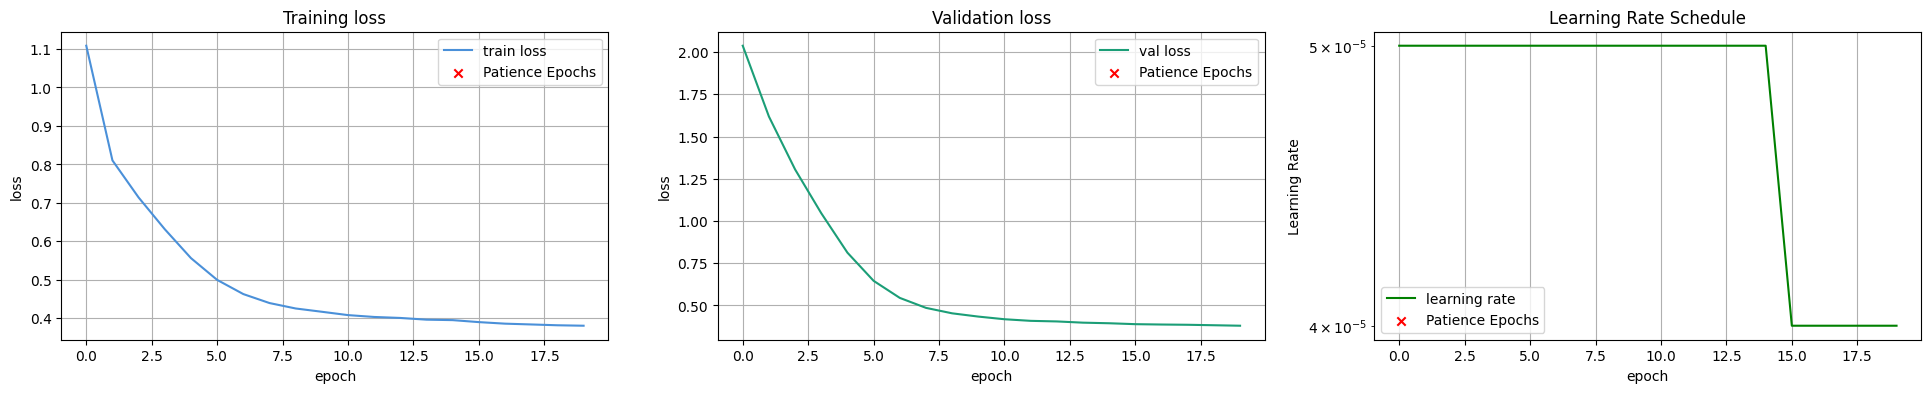

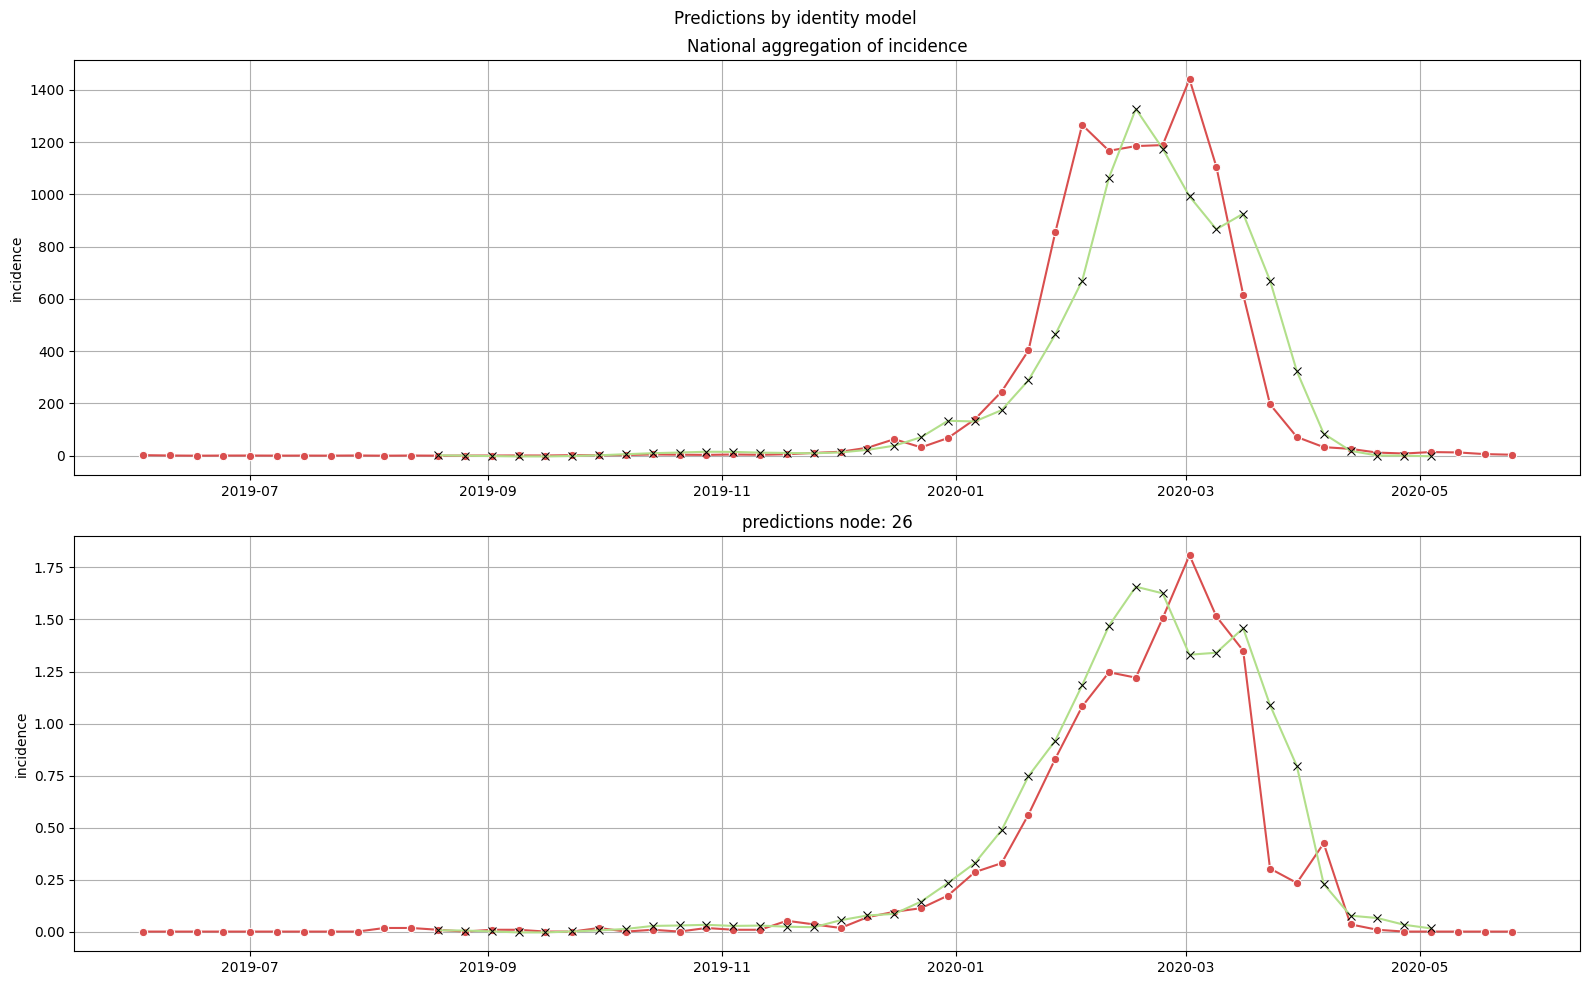

In [1]:
from src.dataloading.gnndataloader import GNNDataLoader
from src.utils import get_data_env
from src.models.spatiotemporal_baseline import TGCNModel
disease_name    = 'influenza'
model           = 'tgcn'
nuts_level      = 'nuts3'
min_date            ='2006-05-15'
max_date            = '2020-06-01'
split_trainval = '2018-06-01'
split_valtest  = '2019-06-01'
split_berlin = False


n_epochs = 20
lr       = 0.00005
min_delta = 0.0001
loss = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'step',
    "scheduler_kwargs"  : {'step_size': 15, 'gamma': 0.8},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 20,
    }

epidata_nuts3 = GNNDataLoader('influenza', get_data_env(), nuts_level='nuts3', min_date=min_date,max_date=max_date, include_population=False, horizon_size = 1, horizon_leadtime = 2, sequence_length=12, split_berlin=split_berlin)
epidata_nuts3.add_time_features()
epidata_nuts3.log_transform_target()
epidata_nuts3.set_splits(split_trainval, split_valtest)
epidata_nuts3.normalize()
epidata_nuts3.add_lagged_features(lags = 1)
epidata_nuts3.finalize()
epidata_nuts3.retrieve_graph('identity_selfmean')
epidata_nuts3.construct_dataloaders()

mainmodel = TGCNModel(epidata_nuts3, name = 'identity model')
mainmodel.set_model_hparams()
mainmodel.set_global_hparams(**global_hparams)
mainmodel.train(verbose = 2, dataloader_snapshot=False, show_loss= True)
mainmodel.forecast('test')
mainmodel.show_forecasts('test', 26)






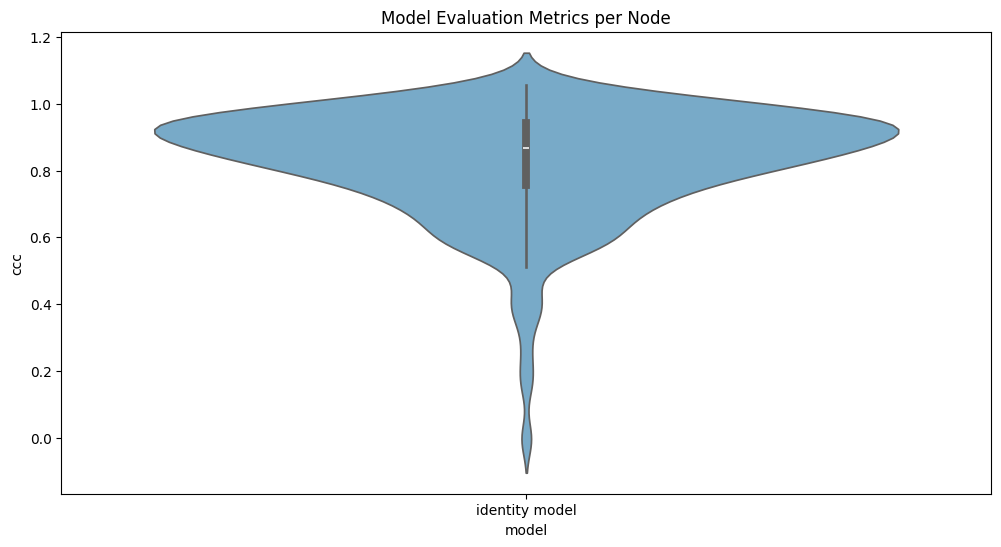

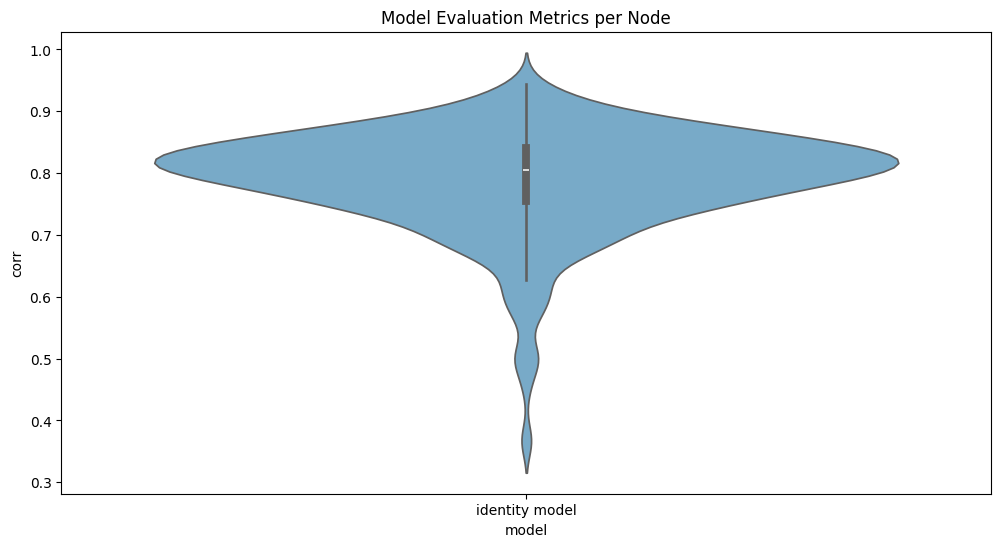

In [2]:
from src.metrics.evaluator import Evaluator
ev = Evaluator(models = [mainmodel])
ev.add_evaluation()
ev.plot_metric(metric = 'ccc')
ev.plot_metric(metric = 'corr')